# Download The dataset

In [1]:
import kagglehub

path = kagglehub.dataset_download("shubhambathwal/flight-price-prediction")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'flight-price-prediction' dataset.
Path to dataset files: /kaggle/input/flight-price-prediction


In [2]:
ls -la /kaggle/input/flight-price-prediction # type: ignore


total 54356
drwxr-sr-x 2 1000 1000        0 Mar 30 10:07 ./
drwxr-xr-x 3 root root     4096 Apr  3 12:06 ../
-rw-r--r-- 1 1000 1000  9868748 Mar 30 10:05 business.csv
-rw-r--r-- 1 1000 1000 24683279 Mar 30 10:05 Clean_Dataset.csv
-rw-r--r-- 1 1000 1000 21096149 Mar 30 10:05 economy.csv


# Import The Libraries

In [ ]:
import warnings
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor 
from sklearn.model_selection import train_test_split
from sklearn.utils.validation import check_is_fitted
from sklearn.compose import TransformedTargetRegressor
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, StandardScaler, MinMaxScaler

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")

# Load The Dataset

In [4]:
df = pd.read_csv(path+'/Clean_Dataset.csv')
df.head()

,Unnamed: 0,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300153 entries, 0 to 300152
Data columns (total 12 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        300153 non-null  int64  
 1   airline           300153 non-null  object 
 2   flight            300153 non-null  object 
 3   source_city       300153 non-null  object 
 4   departure_time    300153 non-null  object 
 5   stops             300153 non-null  object 
 6   arrival_time      300153 non-null  object 
 7   destination_city  300153 non-null  object 
 8   class             300153 non-null  object 
 9   duration          300153 non-null  float64
 10  days_left         300153 non-null  int64  
 11  price             300153 non-null  int64  
dtypes: float64(1), int64(3), object(8)
memory usage: 27.5+ MB


## About the Data

The objective of this dataset is to analyze `the flight booking dataset` obtained from the "Ease My Trip" website. A regression model will be used to predict the flight prices.

### Dataset Summary
- **Source:** Scraped from Ease My Trip website.
- **Records:** ~300,000 observations.
- **Timeline:** Data was collected for 50 days (February to March 2022).
- **Scope:** Covers flight travel between 6 major metro cities in India.

### Features Description

The dataset contains the following features:

| Column Name | Description | Type |
| :--- | :--- | :--- |
| **airline** | The name of the airline company (e.g., Vistara, Air India, Indigo). | Categorical |
| **Flight** | Information about the flight's specific ID code. | Categorical |
| **Source City** | City from which the flight takes off. | Categorical |
| **Departure Time** | Time of day for departure (e.g., Morning, Night, Afternoon). | Categorical |
| **Stops** | Number of stops between source and destination (0, 1, or 2+). | Categorical |
| **Arrival Time** | Time of day for arrival at the destination. | Categorical |
| **Destination City** | City where the flight will land. | Categorical |
| **Class** | Seat class (Economy or Business). | Categorical |
| **Duration** | Total time required to travel between cities in hours. | Continuous |
| **Days Left** | Number of days between booking date and travel date. | Integer |
| **Price** | Target variable representing the ticket cost in INR. | Continuous |

## Splitting The Data

In [6]:
X = df.drop('price', axis=1)
y = df['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, shuffle=True)

print(f"Original dataset shape: {df.shape}")
print(f"X_train shape (Features for training): {X_train.shape}")
print(f"X_test shape (Features for testing): {X_test.shape}")
print(f"y_train shape (Target for training): {y_train.shape}")
print(f"y_test shape (Target for testing): {y_test.shape}")

Original dataset shape: (300153, 12)
X_train shape (Features for training): (240122, 11)
X_test shape (Features for testing): (60031, 11)
y_train shape (Target for training): (240122,)
y_test shape (Target for testing): (60031,)


# Exploratory Data Analysis

In [7]:
X_train.isna().sum()

,0
Unnamed: 0,0
airline,0
flight,0
source_city,0
departure_time,0
stops,0
arrival_time,0
destination_city,0
class,0
duration,0


In [8]:
X_train.duplicated().sum()

np.int64(0)

### The `Unnamed: 0` Column

In [9]:
X_train['Unnamed: 0'].value_counts()

,count
Unnamed: 0,
121958,1
148417,1
36879,1
274531,1
166397,1
...,...
117329,1
2038,1
176994,1


#### Feature Analysis: `Unnamed: 0`

**What is this column?**
By running `value_counts()` on the `Unnamed: 0` column, we can see that every value appears exactly once. This column is simply an artifact from when the dataset was originally saved to a CSV file. Pandas automatically saves the DataFrame's index as a new column unless explicitly told not to (`index=False`). 

**What should we do with it?**
Because this column is just a sequential row identifier, it holds absolutely no mathematical or logical relationship to the flight prices. It is "noise." Passing an ID or index column into a machine learning model can actually confuse the algorithm. 

**Action:** We need to **drop this column** entirely from both our training and testing datasets before proceeding with feature engineering or model training.

### The `airline` Column

In [10]:
X_train['airline'].describe()

,airline
count,240122
unique,6
top,Vistara
freq,102452


In [11]:
X_train['airline'].value_counts()

,count
airline,
Vistara,102452
Air_India,64558
Indigo,34468
GO_FIRST,18556
AirAsia,12848
SpiceJet,7240


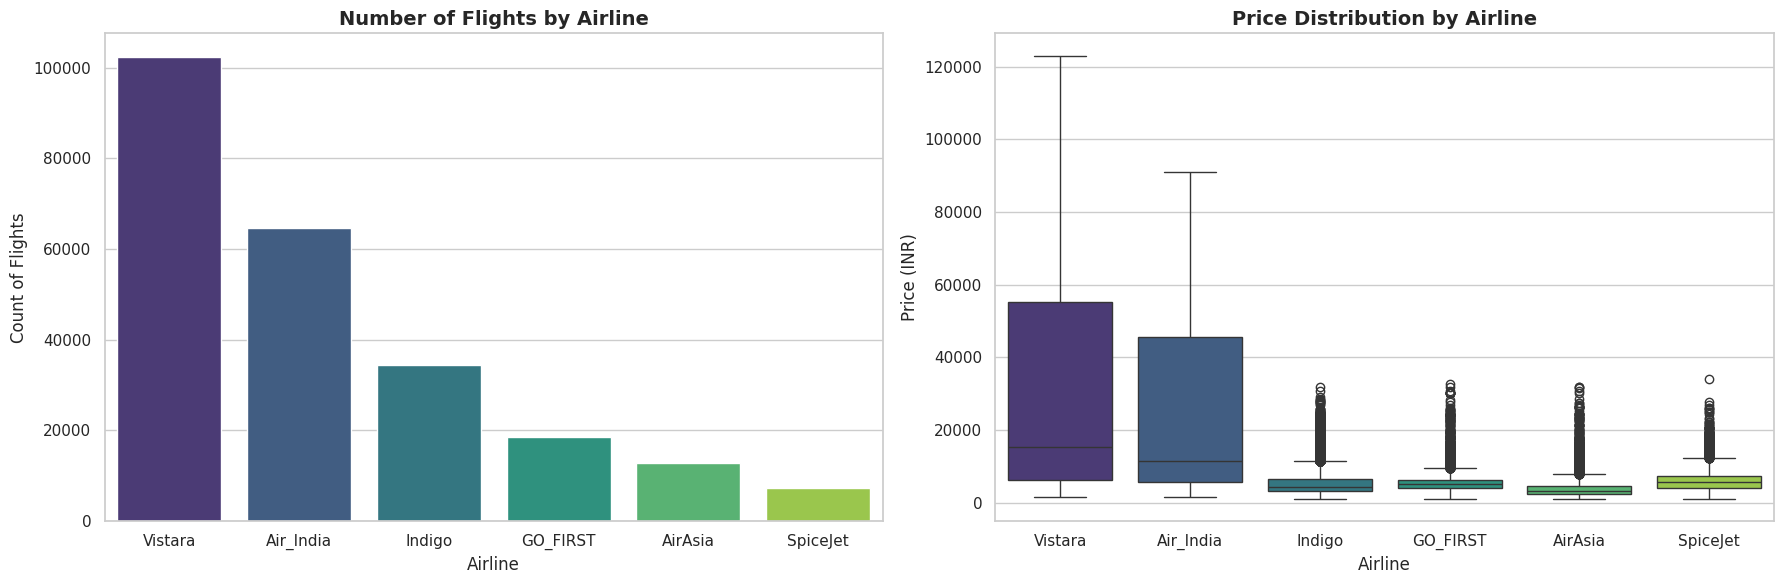

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

sns.countplot(ax=axes[0], data=X_train, x='airline', 
              order=X_train['airline'].value_counts().index, palette='viridis')
axes[0].set_title('Number of Flights by Airline', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Airline', fontsize=12)
axes[0].set_ylabel('Count of Flights', fontsize=12)

sns.boxplot(ax=axes[1], x=X_train['airline'], y=y_train, 
            order=X_train['airline'].value_counts().index, palette='viridis')
axes[1].set_title('Price Distribution by Airline', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Airline', fontsize=12)
axes[1].set_ylabel('Price (INR)', fontsize=12)

plt.tight_layout()
plt.show()

#### Feature Analysis: `airline`

**Data Type Overview:** The statistical summary indicates this column is an `object` data type. In pandas, this means the values are currently stored and should be treated as **strings** representing categorical text. 

**Key Observations:**
* **Market Dominance:** Within our training set of 240,122 records, there are 6 unique airlines. **Vistara** is the most frequent carrier by a wide margin, accounting for 102,452 of the scheduled flights.
* **The Premium vs. Budget Divide:** The price distribution boxplot reveals a stark contrast between airline tiers:
    * *Premium Carriers:* Vistara and Air_India show a massive variance in ticket prices, with medians significantly higher than the rest and upper bounds stretching past 80,000 - 120,000 INR. This wide spread is highly indicative of these airlines offering premium or Business Class seating.
    * *Budget Carriers:* Indigo, GO_FIRST, AirAsia, and SpiceJet operate in a much tighter, lower price bracket. Their median prices are highly uniform and consistently cheaper.
* **Predictive Power:** Because there is such a clear, visual correlation between the airline name and the ticket price range, this feature will be a very strong predictor for our regression model.

### The `flight` Column

In [13]:
X_train['flight'].describe()

,flight
count,240122
unique,1560
top,UK-706
freq,2601


Total unique flight codes in training data: 1560


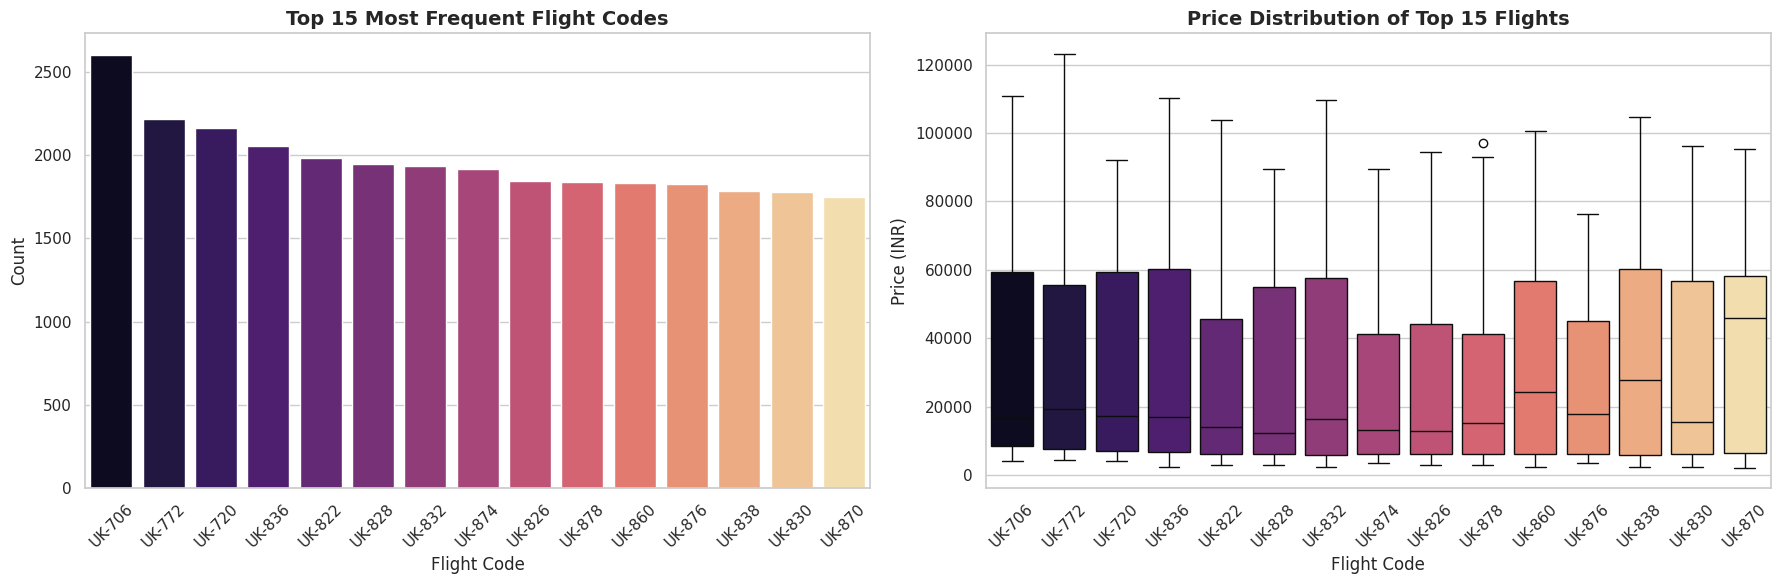

In [14]:
unique_flights = X_train['flight'].nunique()
print(f"Total unique flight codes in training data: {unique_flights}")

top_15_flights = X_train['flight'].value_counts().head(15).index

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

sns.countplot(ax=axes[0], data=X_train[X_train['flight'].isin(top_15_flights)], 
              x='flight', order=top_15_flights, palette='magma')
axes[0].set_title('Top 15 Most Frequent Flight Codes', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Flight Code', fontsize=12)
axes[0].set_ylabel('Count', fontsize=12)
axes[0].tick_params(axis='x', rotation=45) 


sns.boxplot(ax=axes[1], x=X_train.loc[X_train['flight'].isin(top_15_flights), 'flight'], 
            y=y_train[X_train['flight'].isin(top_15_flights)], 
            order=top_15_flights, palette='magma')
axes[1].set_title('Price Distribution of Top 15 Flights', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Flight Code', fontsize=12)
axes[1].set_ylabel('Price (INR)', fontsize=12)
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

#### Feature Analysis: `flight`

**Data Type Overview:** This column is an `object` (string) representing the specific flight number/code.

**Key Observations:**
* **High Cardinality:** Unlike the `airline` column which only had 6 unique values, the `flight` column has over 1,500 unique values. 
* **Pricing Variance:** Looking at the top 15 most frequent flights, we can see that a single flight code (e.g., UK-706) can have a massive variation in price. This makes sense: the flight code represents the scheduled route, but the *price* of that specific flight fluctuates wildly depending on the `class` of the ticket and `days_left` until departure.
* **Redundancy:** The prefix of the flight code (e.g., 'UK' for Vistara, '6E' for Indigo) directly correlates to the `airline` column we already have. 

Therefore, our action will be to **drop this column entirely**. 

Dropping it is the safest approach because it helps prevent **data leakage** and overfitting. Attempting to encode a high-cardinality feature like this (e.g., using Target/Mean Encoding) risks bleeding information from the target variable into the training features. Furthermore, since we already have broader, generalizable features capturing the Airline, Source, Destination, and Time, the highly specific flight code is redundant noise that won't help the model generalize to unseen data.

### The `source_city` Column

In [15]:
X_train['source_city'].describe()

,source_city
count,240122
unique,6
top,Delhi
freq,49067


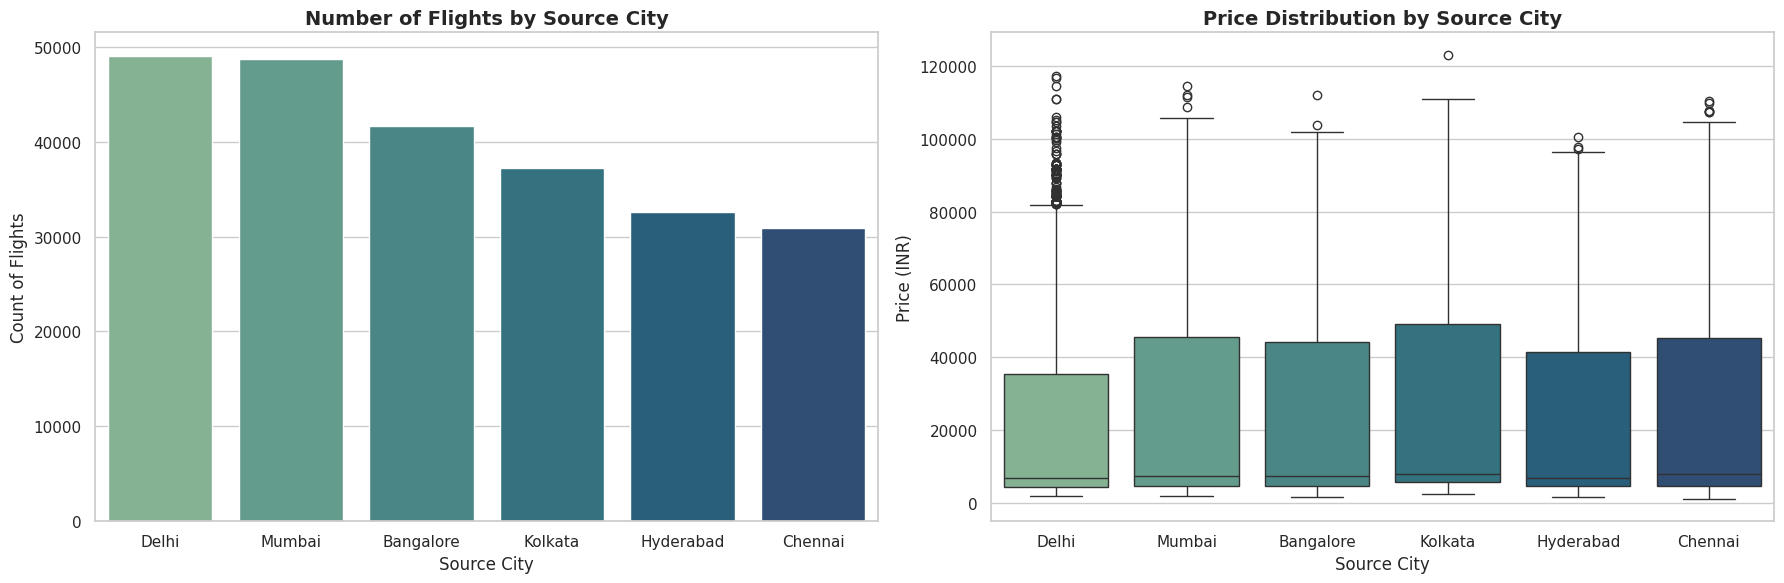

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

city_order = X_train['source_city'].value_counts().index

sns.countplot(ax=axes[0], data=X_train, x='source_city', 
              order=city_order, palette='crest')
axes[0].set_title('Number of Flights by Source City', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Source City', fontsize=12)
axes[0].set_ylabel('Count of Flights', fontsize=12)

sns.boxplot(ax=axes[1], x=X_train['source_city'], y=y_train, 
            order=city_order, palette='crest')
axes[1].set_title('Price Distribution by Source City', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Source City', fontsize=12)
axes[1].set_ylabel('Price (INR)', fontsize=12)

plt.tight_layout()
plt.show()

#### Feature Analysis: `source_city`

**Data Type Overview:** This column is an `object` (string) representing the city from which the flight departs. 

**Key Observations:**
* **Traffic Volume:** Delhi and Mumbai are the busiest hubs, originating the highest number of flights in our dataset. Chennai has the lowest volume of outbound flights.
* **Pricing Uniformity:** Unlike the `airline` column, the boxplots for `source_city` look remarkably similar across the board. The median prices and the spread of outliers (driven by Business Class tickets) are relatively consistent regardless of where the flight starts. 
* **Interaction Potential:** While `source_city` alone might not dictate a massive swing in price, its true predictive power will likely emerge when combined with `destination_city` (e.g., a flight from Delhi to Mumbai might have a very different baseline price than a flight from Delhi to Chennai).

**Preprocessing Action Required:** This is a nominal categorical variable with low cardinality (6 unique cities). There is no inherent mathematical ranking to these cities (Delhi is not "greater than" Mumbai). Therefore, to prepare this column for our regression model without introducing a false hierarchy, we will apply **One-Hot Encoding**.

### The `departure_time` Column

In [17]:
X_train['departure_time'].describe()

,departure_time
count,240122
unique,6
top,Morning
freq,57137


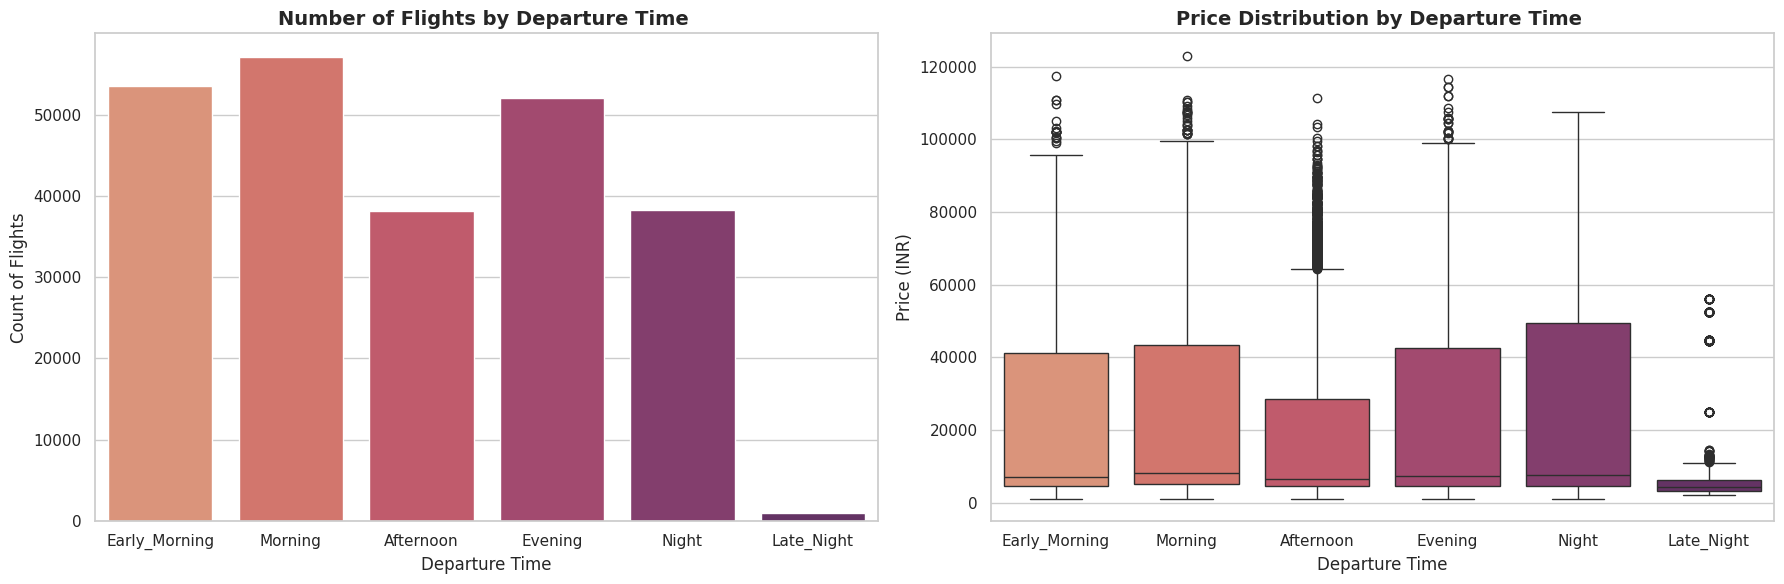

In [18]:
time_order = ['Early_Morning', 'Morning', 'Afternoon', 'Evening', 'Night', 'Late_Night']

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

sns.countplot(ax=axes[0], data=X_train, x='departure_time', 
              order=time_order, palette='flare')
axes[0].set_title('Number of Flights by Departure Time ', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Departure Time', fontsize=12)
axes[0].set_ylabel('Count of Flights', fontsize=12)

sns.boxplot(ax=axes[1], x=X_train['departure_time'], y=y_train, 
            order=time_order, palette='flare')
axes[1].set_title('Price Distribution by Departure Time ', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Departure Time', fontsize=12)
axes[1].set_ylabel('Price (INR)', fontsize=12)

plt.tight_layout()
plt.show()

### Feature Analysis: `departure_time`

**Data Type Overview:** This column is an `object` (string) representing the binned time of day the flight takes off.

**Key Observations:**
* **Flight Availability:** The majority of flights are scheduled during the `Morning` and `Early_Morning` hours, catering heavily to business travelers and day-trippers. Conversely, `Late_Night` (red-eye) flights have the lowest frequency.
* **The "Convenience Premium":** The boxplot reveals an interesting pricing dynamic. Flights departing during highly desirable times (Morning, Evening) tend to have slightly higher median prices and wider spreads. 
* **The "Red-Eye Discount":** `Late_Night` departures are visually distinct from the rest of the day. They have a noticeably lower median price and lack the extreme high-end outliers seen in the morning and evening blocks. Airlines clearly discount these tickets to fill seats at unpopular hours.

**Preprocessing Action Required:** Because this is categorical string data representing sequential time, it must be converted to numbers. 

While the relationship between time and price is non-linear (prices dip, peak, and dip again), time itself has an inherent, chronological order (Early Morning $\rightarrow$ Morning $\rightarrow$ Afternoon, etc.). Because we are planning to use tree-based machine learning models (like Random Forest or XGBoost), which are excellent at learning non-linear splits and thresholds, we do not need to worry about the model assuming a straight-line mathematical relationship.

Therefore, our best approach is **Ordinal Encoding**. We will map the time blocks to integers in chronological order:
* 'Early_Morning' $\rightarrow$ 0
* 'Morning' $\rightarrow$ 1
* 'Afternoon' $\rightarrow$ 2
* 'Evening' $\rightarrow$ 3
* 'Night' $\rightarrow$ 4
* 'Late_Night' $\rightarrow$ 5

### The `stops` Column

In [19]:
X_train['stops'].describe()

,stops
count,240122
unique,3
top,one
freq,200570


In [20]:
X_train['stops'].value_counts()

,count
stops,
one,200570
zero,28887
two_or_more,10665


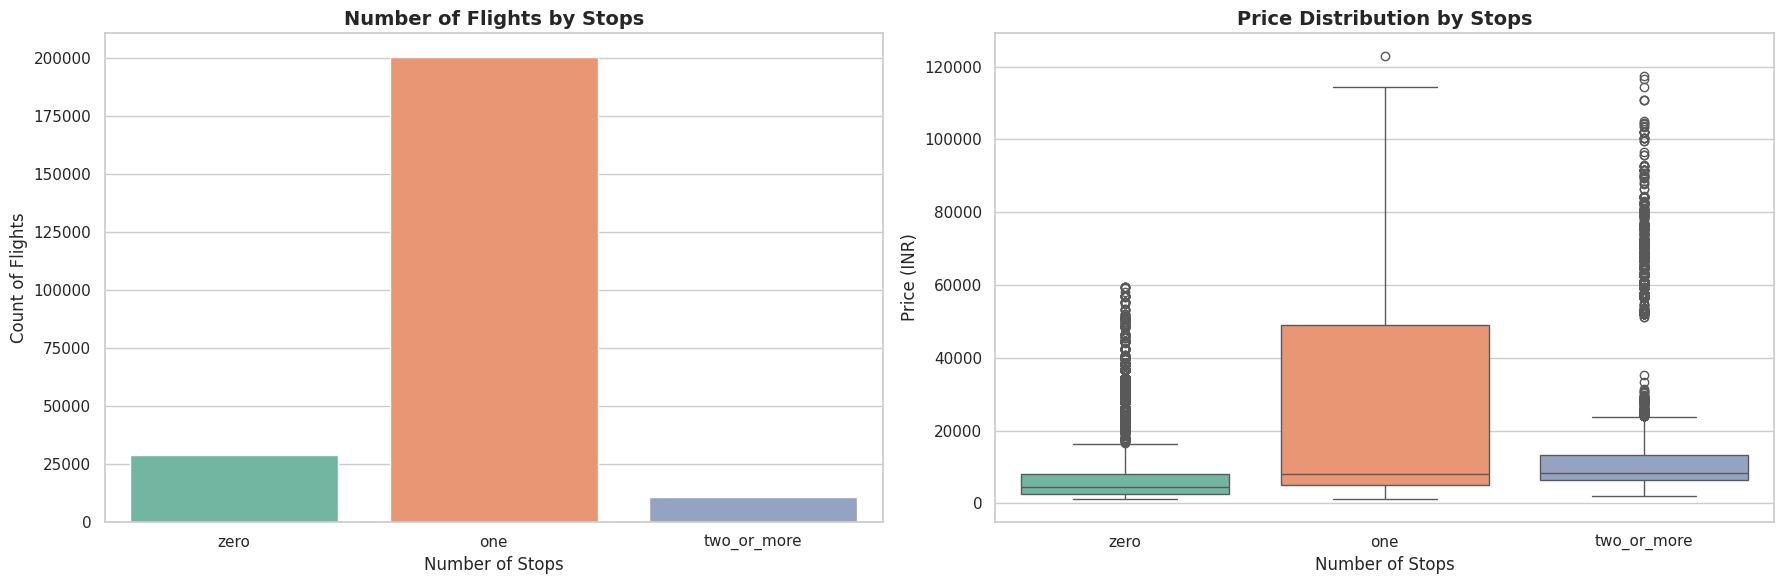

In [21]:
stop_order = ['zero', 'one', 'two_or_more'] 

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

sns.countplot(ax=axes[0], data=X_train, x='stops', 
              order=stop_order, palette='Set2')
axes[0].set_title('Number of Flights by Stops', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Number of Stops', fontsize=12)
axes[0].set_ylabel('Count of Flights', fontsize=12)

sns.boxplot(ax=axes[1], x=X_train['stops'], y=y_train, 
            order=stop_order, palette='Set2')
axes[1].set_title('Price Distribution by Stops', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Number of Stops', fontsize=12)
axes[1].set_ylabel('Price (INR)', fontsize=12)

plt.tight_layout()
plt.show()

Why is The one-stop flight more expensive than the direct flight?

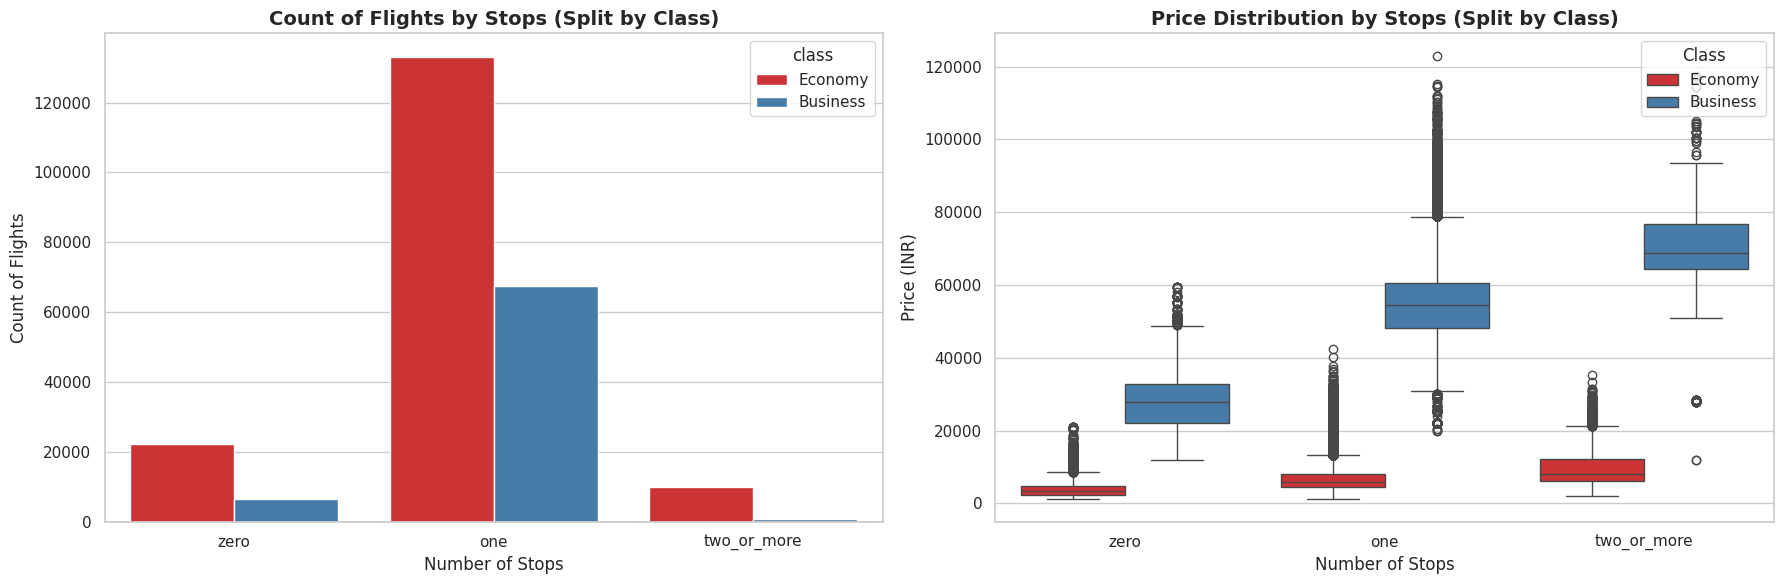

In [22]:
stop_order = ['zero', 'one', 'two_or_more']

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

sns.countplot(ax=axes[0], data=X_train, x='stops', hue='class', 
              order=stop_order, palette='Set1')
axes[0].set_title('Count of Flights by Stops (Split by Class)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Number of Stops', fontsize=12)
axes[0].set_ylabel('Count of Flights', fontsize=12)


sns.boxplot(ax=axes[1], data=df, x='stops', y='price', hue='class', 
            order=stop_order, palette='Set1')
axes[1].set_title('Price Distribution by Stops (Split by Class)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Number of Stops', fontsize=12)
axes[1].set_ylabel('Price (INR)', fontsize=12)

axes[1].legend(title='Class', loc='upper right')

plt.tight_layout()
plt.show()

Analyzing `stops` by ticket `class` explains two primary pricing anomalies:

1. The "One Stop" Price Mystery:
Previously, 1-stop flights seemed more expensive than direct flights. This is because **Business Class** tickets—which cost 5–10x more than Economy—primarily fall into the 1-stop category, skewing the average upward. In reality, Economy prices stay relatively consistent regardless of stops.

2. The Extreme Outliers:
The massive price spikes (100,000+ INR) in the `two_or_more` stops category are driven by a small volume of ultra-premium **Business Class** flights. While rare, these specific tickets represent the extreme outliers seen in the data.

#### Feature Analysis: `stops`

**Data Type Overview:** This column is an `object` (string) representing the number of layovers between the source and destination. The values are typically 'zero', 'one', and 'two_or_more'.

**Key Observations:**
* **Frequency:** Flights with exactly 'one' stop are the most common in this dataset, while flights with 'two_or_more' stops are quite rare.
* **Pricing Dynamics:** Interestingly, direct flights ('zero' stops) tend to have a lower median price than flights with 'one' stop. This might seem counter-intuitive (as direct flights are usually considered a premium convenience). However, in this market, direct routes between major hubs are heavily saturated by budget airlines driving prices down, whereas 1-stop flights might represent longer distances or routes monopolized by premium carriers. 

**Preprocessing Action Required:** the `stops` column has a strict mathematical order: $0 < 1 < 2$. 

If we used One-Hot Encoding here, we would lose that valuable mathematical relationship. Therefore, this column requires **Ordinal Encoding**. We will replace the string categories with ordered integers:
* 'zero' $\rightarrow$ 0
* 'one' $\rightarrow$ 1
* 'two_or_more' $\rightarrow$ 2

### The `arrival_time` Column

In [23]:
X_train['arrival_time'].describe()

,arrival_time
count,240122
unique,6
top,Night
freq,73438


In [24]:
X_train['arrival_time'].value_counts()

,count
arrival_time,
Night,73438
Evening,62637
Morning,50146
Afternoon,30456
Early_Morning,12330
Late_Night,11115


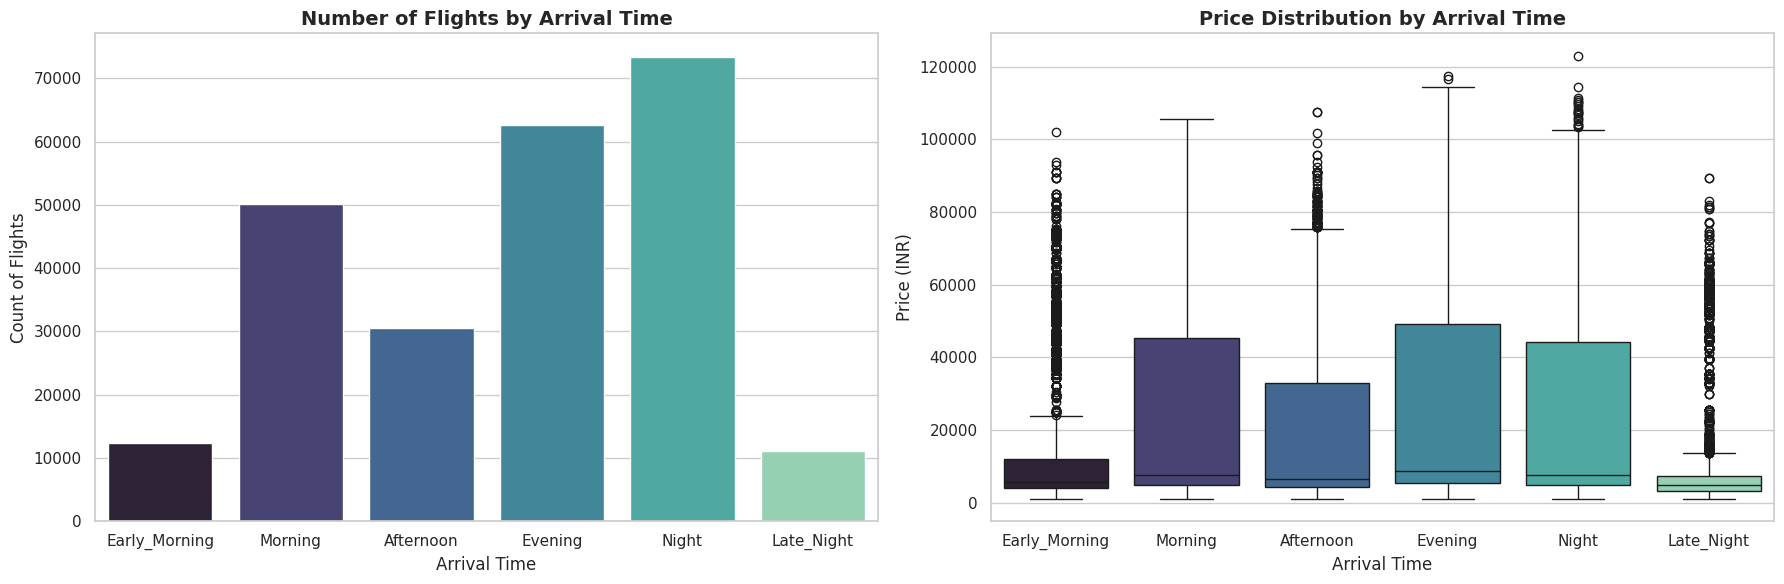

In [25]:
time_order = ['Early_Morning', 'Morning', 'Afternoon', 'Evening', 'Night', 'Late_Night']

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

sns.countplot(ax=axes[0], data=X_train, x='arrival_time', 
              order=time_order, palette='mako')
axes[0].set_title('Number of Flights by Arrival Time', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Arrival Time', fontsize=12)
axes[0].set_ylabel('Count of Flights', fontsize=12)

sns.boxplot(ax=axes[1], x=X_train['arrival_time'], y=y_train, 
            order=time_order, palette='mako')
axes[1].set_title('Price Distribution by Arrival Time', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Arrival Time', fontsize=12)
axes[1].set_ylabel('Price (INR)', fontsize=12)

plt.tight_layout()
plt.show()

## Feature Analysis: `arrival_time`

**Data Type Overview:** This column is an `object` (string) representing the binned time of day the flight lands at its destination.

**Key Observations:**
* **Traffic Flow:** The volume of arriving flights peaks during the **Night** and **Evening** hours. This reflects typical travel patterns where passengers depart early and arrive later in the day.
* **The "Inconvenience Discount":** Flights landing during **Late_Night** and **Early_Morning** (red-eye arrivals) show noticeably lower median prices. Airlines often discount these slots because arriving at 2:00 AM or 5:00 AM is less desirable for travelers.
* **Premium Arrival Windows:** **Evening** arrivals command the highest median price, as this window aligns perfectly with the end of the standard business day for corporate travelers.

**Preprocessing Action Required:** While the relationship between time and price is non-linear (dipping and peaking throughout the day), these categories follow a natural chronological cycle.

To preserve this temporal sequence while keeping the feature set efficient for tree-based models, we will apply **Ordinal Encoding**. We will map the time blocks to integers representing the progression of a 24-hour day:
* **Early_Morning** $\rightarrow$ 0
* **Morning** $\rightarrow$ 1
* **Afternoon** $\rightarrow$ 2
* **Evening** $\rightarrow$ 3
* **Night** $\rightarrow$ 4
* **Late_Night** $\rightarrow$ 5

### The `destination_city` Column

In [26]:
X_train['destination_city'].describe()

,destination_city
count,240122
unique,6
top,Mumbai
freq,47309


In [27]:
X_train['destination_city'].value_counts()

,count
destination_city,
Mumbai,47309
Delhi,45814
Bangalore,40989
Kolkata,39601
Hyderabad,34091
Chennai,32318


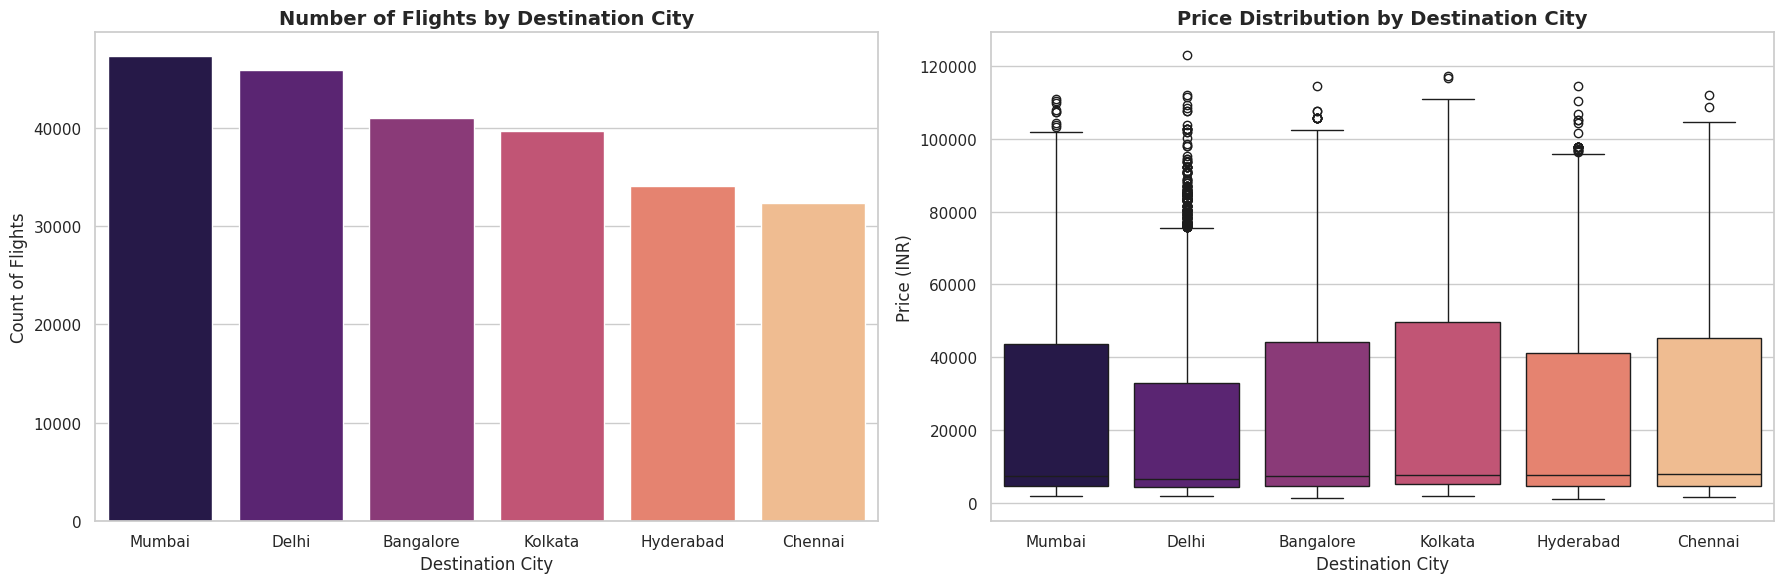

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

dest_city_order = X_train['destination_city'].value_counts().index

sns.countplot(ax=axes[0], data=X_train, x='destination_city', 
              order=dest_city_order, palette='magma')
axes[0].set_title('Number of Flights by Destination City', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Destination City', fontsize=12)
axes[0].set_ylabel('Count of Flights', fontsize=12)

sns.boxplot(ax=axes[1], x=X_train['destination_city'], y=y_train, 
            order=dest_city_order, palette='magma')
axes[1].set_title('Price Distribution by Destination City', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Destination City', fontsize=12)
axes[1].set_ylabel('Price (INR)', fontsize=12)

plt.tight_layout()
plt.show()

#### Feature Analysis: `destination_city`

**Data Type Overview:** This column is an `object` (string) representing the city where the flight lands. It contains the exact same 6 major Indian cities as the `source_city` column.

**Key Observations:**
* **Traffic Symmetry:** As expected, the volume of flights arriving in these cities closely mirrors the volume of flights departing from them. Mumbai and Delhi are the most frequent destinations, acting as the primary hubs for domestic travel, while Chennai remains the least frequented.
* **Pricing Uniformity:** Similar to the source city analysis, the destination city alone does not show massive, distinct variations in median price. The extreme upper outliers are consistently present across all cities, heavily driven by the `class` (Business tier) rather than the location itself.
* **Route Dynamics:** While the standalone destination city isn't a massive price differentiator, the combination of `source_city` and `destination_city` (the actual route) will likely be a strong feature for the model to learn.

**Preprocessing Action Required:** Because this is a nominal categorical variable with no inherent mathematical order (Mumbai > Delhi makes no mathematical sense), we must apply **One-Hot Encoding**.

### The `class` Column

In [29]:
X_train['class'].describe()

,class
count,240122
unique,2
top,Economy
freq,165350


In [30]:
X_train['class'].value_counts()

,count
class,
Economy,165350
Business,74772


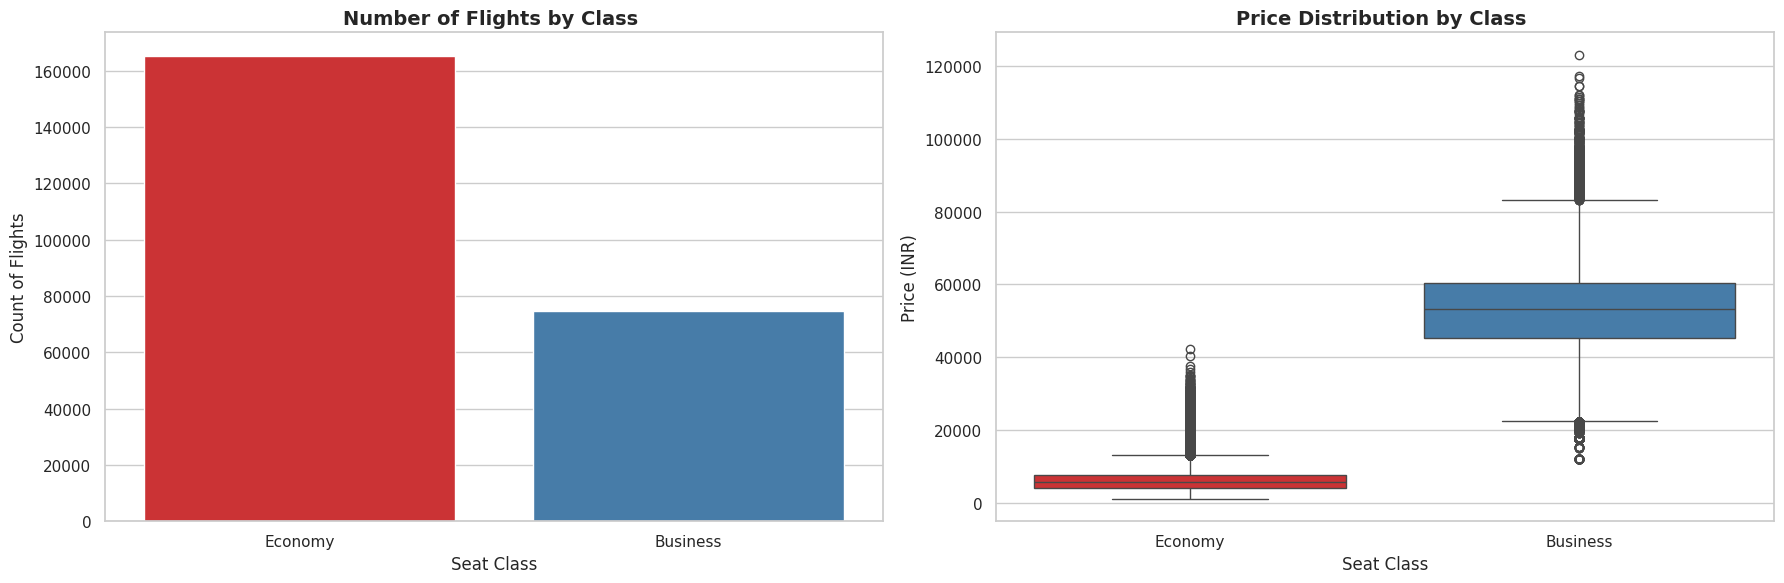

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

sns.countplot(ax=axes[0], data=X_train, x='class', palette='Set1')
axes[0].set_title('Number of Flights by Class ', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Seat Class', fontsize=12)
axes[0].set_ylabel('Count of Flights', fontsize=12)

sns.boxplot(ax=axes[1], x=X_train['class'], y=y_train, palette='Set1')
axes[1].set_title('Price Distribution by Class ', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Seat Class', fontsize=12)
axes[1].set_ylabel('Price (INR)', fontsize=12)

plt.tight_layout()
plt.show()

#### Feature Analysis: `class`

**Data Type Overview:** This column is an `object` (string) representing the seating tier of the ticket. There are only two unique values: 'Economy' and 'Business'.

**Key Observations:**
* **Class Imbalance:** The vast majority of flights in this dataset are Economy class. Business class tickets make up a much smaller percentage of the overall data. 
* **The Ultimate Price Driver:** The boxplot shows a night-and-day difference in pricing. The *minimum* price of a Business class ticket is often higher than the *maximum* price of most Economy tickets. There is almost zero overlap between the two distributions. This indicates that `class` will likely be the single most powerful predictive feature for our machine learning model.

**Preprocessing Action Required:** Because there are only two categories, and one is explicitly a "higher" premium tier than the other, we will use **Binary Encoding** (a form of Ordinal Encoding). We will map the string values to integers:
* 'Economy' $\rightarrow$ 0
* 'Business' $\rightarrow$ 1

This keeps our dataset lean (only one column instead of two for One-Hot) and preserves the logical hierarchy that Business costs more than Economy.

### The `duration` Column

In [32]:
X_train['duration'].head()

,duration
148417,19.42
36879,7.00
274531,21.17
166397,10.25
272722,26.50


In [33]:
X_train['duration'].describe()

,duration
count,240122.000000
mean,12.213243
std,7.194323
min,0.830000
25%,6.750000
50%,11.250000
75%,16.170000
max,49.830000


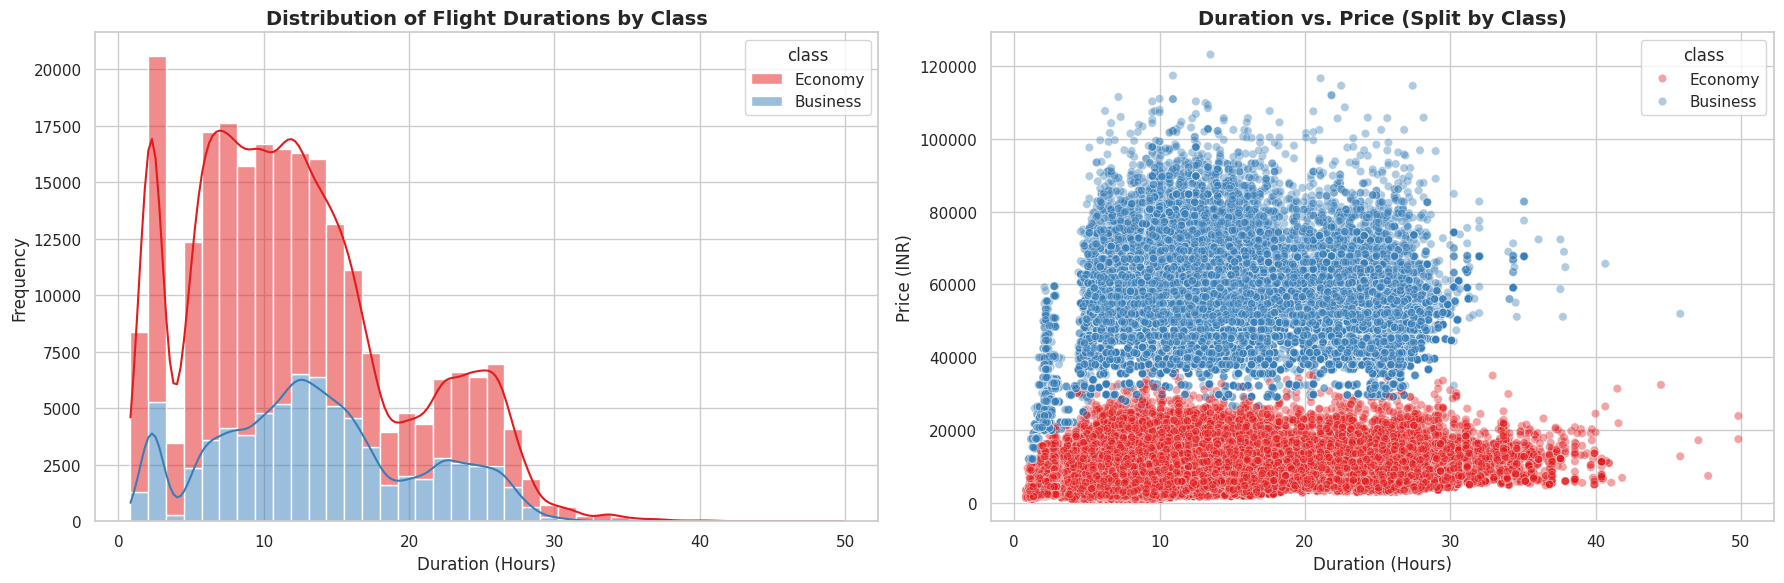

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))


sns.histplot(ax=axes[0], data=X_train, x='duration', hue='class', 
             multiple="stack", bins=40, kde=True, palette='Set1')
axes[0].set_title('Distribution of Flight Durations by Class', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Duration (Hours)', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)

sns.scatterplot(ax=axes[1], x=X_train['duration'], y=y_train, 
                hue=X_train['class'], alpha=0.4, palette='Set1')
axes[1].set_title('Duration vs. Price (Split by Class)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Duration (Hours)', fontsize=12)
axes[1].set_ylabel('Price (INR)', fontsize=12)

plt.tight_layout()
plt.show()

#### Feature Analysis: `duration`

**Data Type Overview:** This column is a `float64` (continuous numerical) representing the total travel time in hours.

**Key Observations:**
* **Distribution (Histogram):** The overall distribution is heavily **right-skewed**, with the vast majority of flights concentrated between 2 to 15 hours, and a long tail extending out past 40 hours. The distinct "waves" in the data are heavily driven by the number of layovers rather than the ticket class.
* **The "Two-Tier" Price Bands (Scatter Plot):** The scatter plot reveals a massive price divide driven by `class`. Economy tickets form a dense lower band under 30,000 INR, while Business tickets form a distinct upper band starting near 40,000 INR. Within each band, longer durations show a slight upward trend in price.

**Advanced Preprocessing Action Required:**
This continuous numerical column requires a two-step preprocessing approach:

1.  **Log Transformation (`np.log1p`):** Because the distribution is heavily right-skewed, we will first apply a $\log(x+1)$ transformation. This will compress the long tail of 40+ hour flights, bringing the data much closer to a normal distribution. Models like Linear Regression perform significantly better when features are normally distributed.
2.  **Feature Scaling (`StandardScaler`):** After normalizing the shape, we must normalize the scale. Our encoded categorical features (like `class`) will be on a tiny scale of 0 to 1, while the log-transformed duration will still be larger. We will use `StandardScaler` to center the data around a mean of 0 with a standard deviation of 1, preventing the model from artificially assigning too much weight to this feature simply because its numbers are larger.

### The `days_left` Column

In [35]:
X_train['days_left'].head()

,days_left
148417,6
36879,13
274531,44
166397,11
272722,5


In [36]:
X_train['days_left'].describe()

,days_left
count,240122.000000
mean,26.011594
std,13.568291
min,1.000000
25%,15.000000
50%,26.000000
75%,38.000000
max,49.000000


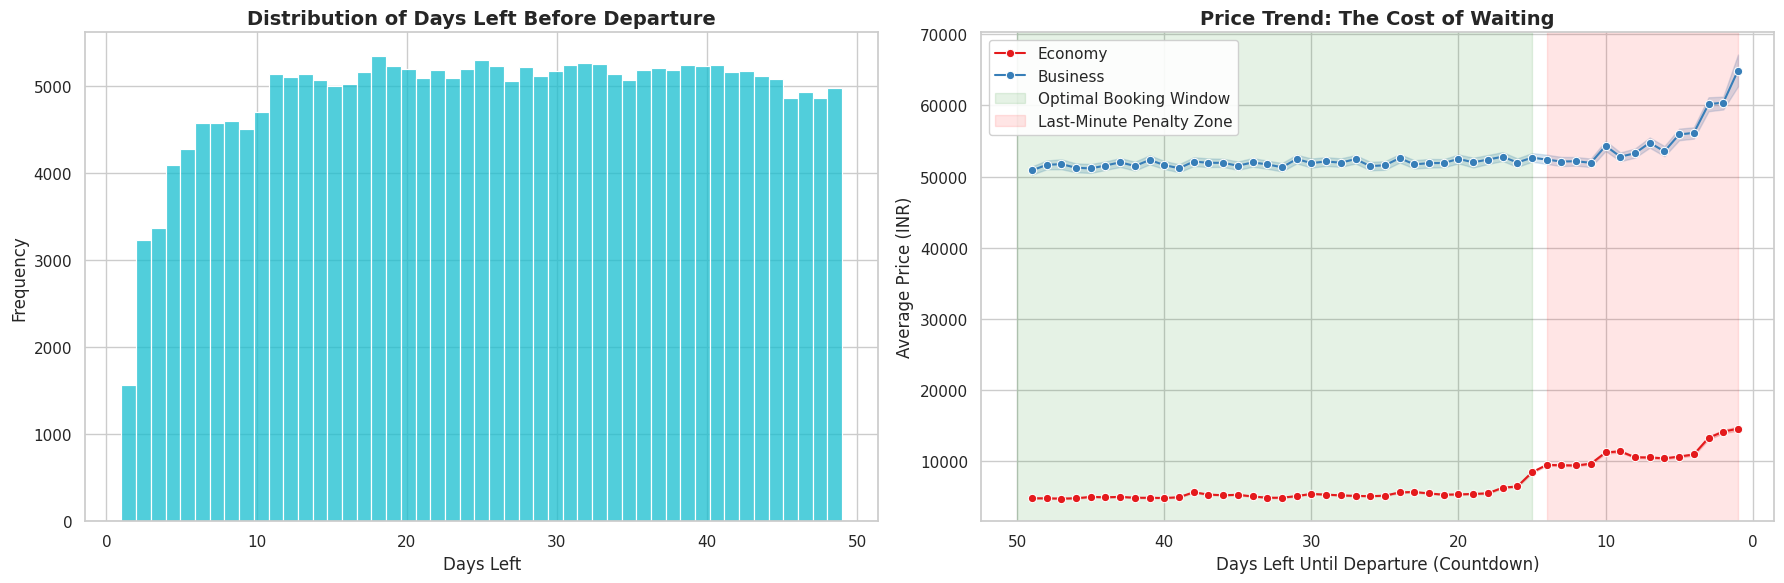

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

sns.histplot(ax=axes[0], data=X_train, x='days_left', bins=49, color='#17becf', kde=False)
axes[0].set_title('Distribution of Days Left Before Departure', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Days Left', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)


sns.lineplot(ax=axes[1], x=X_train['days_left'], y=y_train, 
             hue=X_train['class'], palette='Set1', marker='o')

axes[1].set_title('Price Trend: The Cost of Waiting', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Days Left Until Departure (Countdown)', fontsize=12)
axes[1].set_ylabel('Average Price (INR)', fontsize=12)

axes[1].invert_xaxis()

axes[1].axvspan(50, 15, color='green', alpha=0.1, label='Optimal Booking Window')

axes[1].axvspan(14, 1, color='red', alpha=0.1, label='Last-Minute Penalty Zone')

handles, labels = axes[1].get_legend_handles_labels()
axes[1].legend(handles=handles, labels=labels, loc='upper left', framealpha=0.9)

plt.tight_layout()
plt.show()

#### Feature Analysis: `days_left`

**Data Type Overview:** This column is an `int64` (discrete numerical) representing the number of days between the booking date and the flight departure date.

**Key Observations:**
* **Distribution (Histogram):** The frequency of data points across the `days_left` timeline is relatively uniform. This is typical for a systematically scraped dataset, meaning the web scraper collected a roughly equal number of flight options for flights departing in 10 days, 20 days, 50 days, etc.
* **The "Last-Minute Penalty" (Line Plot):** By plotting the average price over time and reading the chart from left to right (as a countdown to departure), the classic airline pricing strategy becomes undeniable:
    * **The Sweet Spot:** Prices remain relatively stable and flat when booking anywhere from 50 days down to about 20 days in advance.
    * **The Spike:** Once you hit the 15-day mark, the average price begins to climb steadily. 
    * **The Penalty:** Booking within 1 to 3 days of departure results in a massive price spike for both Economy and Business class tickets. Airlines know that last-minute travelers (often corporate flyers or emergency travelers) are price-inelastic and will pay whatever is necessary.

**Preprocessing Action Required:** Because this is already a numerical column, it does not require encoding. However, like our `duration` column, its raw values (ranging from 1 to 50) are much larger than our 0-and-1 encoded categorical variables. 

To ensure our machine learning model treats all features fairly, we must apply **Feature Scaling**. We will pass this column through a `MinMaxScaler` to normalize its values alongside the transformed `duration` feature.

### The `price` Column

In [38]:
y_train.describe()

,price
count,240122.000000
mean,20888.572417
std,22696.150093
min,1105.000000
25%,4783.000000
50%,7426.000000
75%,42521.000000
max,123071.000000


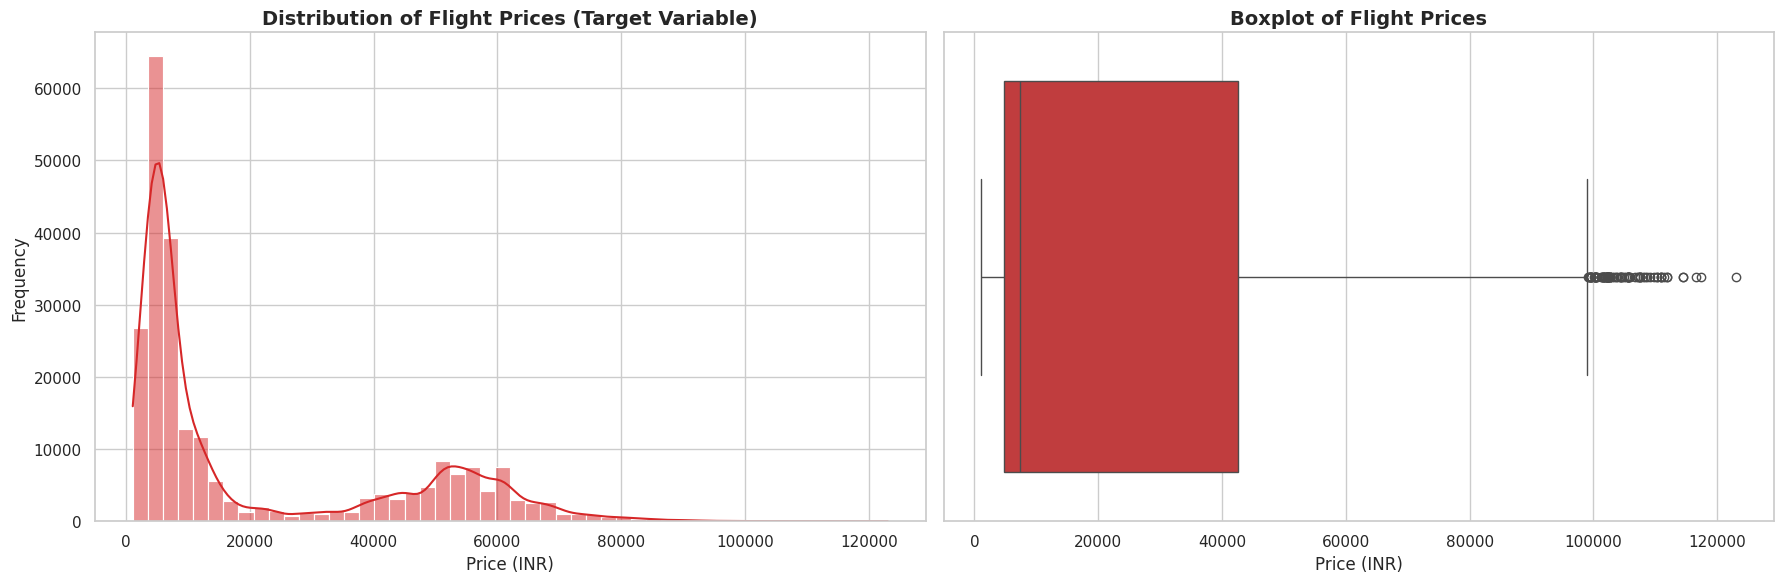

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

sns.histplot(ax=axes[0], data=y_train, bins=50, kde=True, color='#d62728')
axes[0].set_title('Distribution of Flight Prices (Target Variable)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Price (INR)', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)

sns.boxplot(ax=axes[1], x=y_train, color='#d62728')
axes[1].set_title('Boxplot of Flight Prices', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Price (INR)', fontsize=12)

plt.tight_layout()
plt.show()

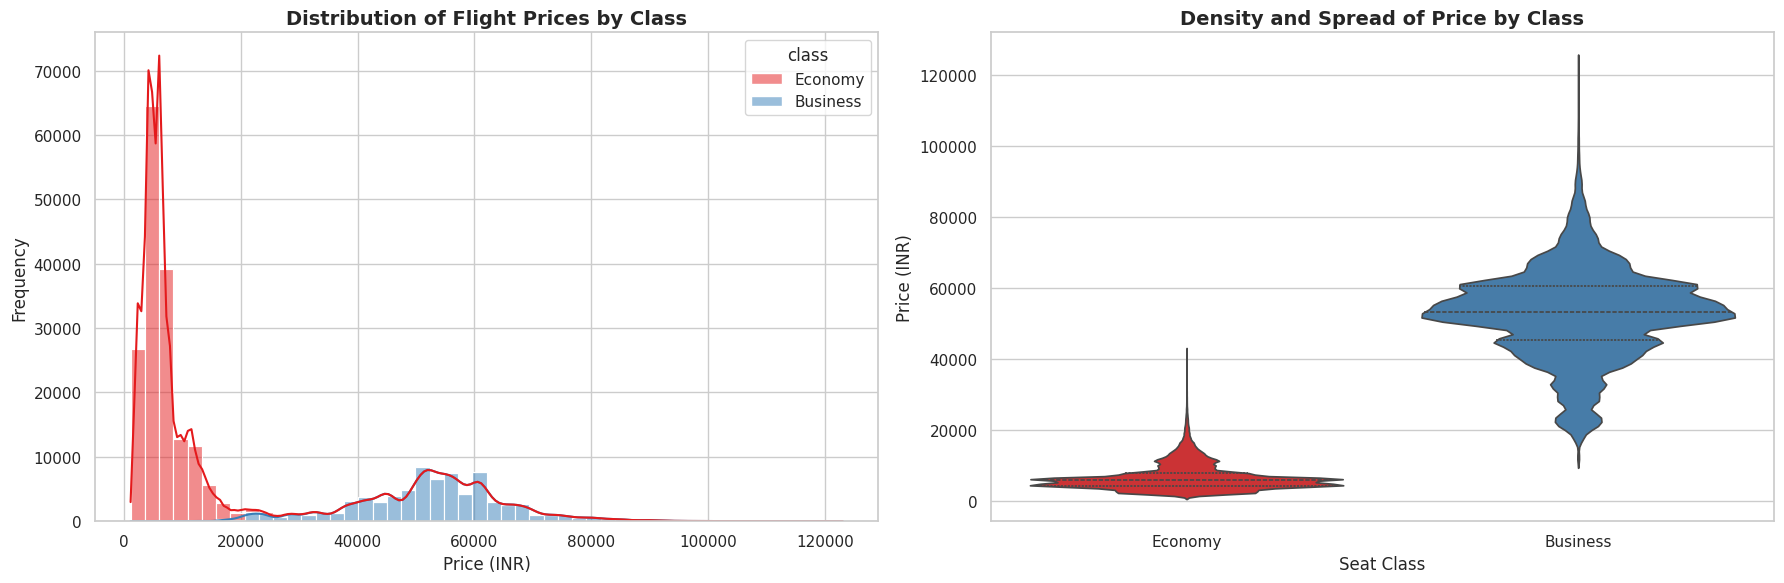

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))


sns.histplot(ax=axes[0], x=y_train, hue=X_train['class'], 
             multiple="stack", bins=50, kde=True, palette='Set1')
axes[0].set_title('Distribution of Flight Prices by Class', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Price (INR)', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)

sns.violinplot(ax=axes[1], x=X_train['class'], y=y_train, 
               palette='Set1', inner='quartile')
axes[1].set_title('Density and Spread of Price by Class', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Seat Class', fontsize=12)
axes[1].set_ylabel('Price (INR)', fontsize=12)

plt.tight_layout()
plt.show()

### Target Variable Analysis: `price`

**Data Type Overview:** This is an `int64` (continuous numerical) column and serves as the **Target Variable** for our regression model.

**Key Observations:**
* **Bimodal / Right-Skewed Distribution:** The histogram reveals a heavily right-skewed distribution with two distinct peaks (a bimodal shape). 
    * The massive spike on the left represents the **Economy class** tickets, clustering heavily between 2,000 and 20,000 INR.
    * The smaller, wider mound on the right (starting around 40,000 INR and peaking near 60,000 INR) represents the **Business class** tickets.
* **Extreme Outliers:** The boxplot clearly shows a dense concentration of data points at the lower end, with a very long tail of outliers stretching well past 100,000 INR. These are ultra-premium, last-minute, or multi-stop Business class fares.

**Modeling Implications:**
Because our target variable is not normally distributed (it is heavily skewed and bimodal), linear regression models might struggle to predict the ultra-high prices accurately, potentially leading to skewed residuals (errors). 

*Advanced Note:* Just like we did with the `duration` feature, applying a **Log Transformation (`np.log1p`) to the target variable (`y_train`)** is a very common technique to pull in that long tail and make the target closer to a normal distribution. If we do this, we must remember to apply the inverse transformation (`np.expm1`) to our model's final predictions so they make sense in real-world Rupees!

# Preprocessing

In [41]:
class FeatureDropper(BaseEstimator, TransformerMixin):
    def __init__(self, columns_to_drop):
        self.columns_to_drop = columns_to_drop

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X_copy = X.copy()
        cols_to_drop = [col for col in self.columns_to_drop if col in X_copy.columns]
        return X_copy.drop(columns=cols_to_drop)

class FlightOrdinalEncoder(BaseEstimator, TransformerMixin):
    def __init__(self):
        self.columns_to_encode = ['class', 'stops', 'departure_time', 'arrival_time']
        self.category_orders = [
            ['Economy', 'Business'],                                                        # class
            ['zero', 'one', 'two_or_more'],                                                 # stops
            ['Early_Morning', 'Morning', 'Afternoon', 'Evening', 'Night', 'Late_Night'],    # departure_time
            ['Early_Morning', 'Morning', 'Afternoon', 'Evening', 'Night', 'Late_Night'],    # arrival_time
        ]
        self.encoder = OrdinalEncoder(
            categories=self.category_orders,
            handle_unknown='use_encoded_value',
            unknown_value=-1
        )

    def fit(self, X, y=None):
        self.encoder.fit(X[self.columns_to_encode])
        self.is_fitted_ = True
        return self

    def transform(self, X):
        check_is_fitted(self, 'is_fitted_')
        X_copy = X.copy()
        X_copy[self.columns_to_encode] = self.encoder.transform(X_copy[self.columns_to_encode])
        return X_copy


class Log1pTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, columns_to_log):
        self.columns_to_log = columns_to_log

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X_copy = X.copy()
        for col in self.columns_to_log:
            if col in X_copy.columns:
                X_copy[col] = np.log1p(X_copy[col])
        return X_copy


final_transformer = ColumnTransformer(
    transformers=[
        ('scaler_continuous', StandardScaler(),
         ['duration']),

        ('scaler_uniform', MinMaxScaler(),
         ['days_left']),

        ('ordinal_passthrough', 'passthrough',
         ['class', 'stops', 'departure_time', 'arrival_time']),

        ('ohe', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'),
         ['airline', 'source_city', 'destination_city']),
    ],
    remainder='drop'
)

In [42]:
preprocessing_pipeline = Pipeline(steps=[
    ('dropper',         FeatureDropper(columns_to_drop=['Unnamed: 0', 'flight'])),
    ('ordinal_encoder', FlightOrdinalEncoder()),
    ('log_transform',   Log1pTransformer(columns_to_log=['duration'])),
    ('final_processor', final_transformer),
])


X_train_processed = preprocessing_pipeline.fit_transform(X_train)
X_test_processed  = preprocessing_pipeline.transform(X_test)   

print("✅ Preprocessing Pipeline executed successfully.")
print(f"X_train_processed shape: {X_train_processed.shape}")
print(f"X_test_processed shape : {X_test_processed.shape}")


ohe_feature_names = (
    preprocessing_pipeline
    .named_steps['final_processor']
    .named_transformers_['ohe']
    .get_feature_names_out(['airline', 'source_city', 'destination_city'])
)

all_feature_names = (
    ['duration', 'days_left',
     'class', 'stops', 'departure_time', 'arrival_time']
    + list(ohe_feature_names)
)

X_train_processed = pd.DataFrame(X_train_processed, columns=all_feature_names)
X_test_processed  = pd.DataFrame(X_test_processed,  columns=all_feature_names)

X_train_processed.head()

✅ Preprocessing Pipeline executed successfully.
X_train_processed shape: (240122, 21)
X_test_processed shape : (60031, 21)


,duration,days_left,class,stops,departure_time,arrival_time,airline_Air_India,airline_GO_FIRST,airline_Indigo,airline_SpiceJet,...,source_city_Chennai,source_city_Delhi,source_city_Hyderabad,source_city_Kolkata,source_city_Mumbai,destination_city_Chennai,destination_city_Delhi,destination_city_Hyderabad,destination_city_Kolkata,destination_city_Mumbai
0,0.963022,0.104167,0.0,1.0,2.0,1.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0
1,-0.517669,0.250000,0.0,2.0,2.0,4.0,0.0,0.0,1.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
2,1.092948,0.895833,1.0,1.0,2.0,2.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0
3,0.021037,0.208333,0.0,1.0,4.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,1.433379,0.083333,1.0,1.0,4.0,4.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0


# Model

In [43]:
preprocessing_pipeline = Pipeline(steps=[
    ('dropper',         FeatureDropper(columns_to_drop=['Unnamed: 0', 'flight'])),
    ('ordinal_encoder', FlightOrdinalEncoder()),
    ('log_transform',   Log1pTransformer(columns_to_log=['duration'])),
    ('final_processor', final_transformer),
])


model_with_target_transform = TransformedTargetRegressor(
    regressor=RandomForestRegressor(n_estimators=100, random_state=42),
    func=np.log1p, 
    inverse_func=np.expm1
)

full_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessing_pipeline),
    ('regressor',    model_with_target_transform)
])


full_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 Pipeline(steps=[('dropper',
                                  FeatureDropper(columns_to_drop=['Unnamed: 0',
                                                                  'flight'])),
                                 ('ordinal_encoder', FlightOrdinalEncoder()),
                                 ('log_transform',
                                  Log1pTransformer(columns_to_log=['duration'])),
                                 ('final_processor',
                                  ColumnTransformer(transformers=[('scaler_continuous',
                                                                   StandardScaler(),
                                                                   ['duration']),
                                                                  ('scaler_uniform',
                                                                   MinMaxS...
                                                                  ('ordinal_passthrough',
                                                                   'passthrough',
                                                                   ['class',
                                                                    'stops',
                                                                    'departure_time',
                                                                    'arrival_time']),
                                                                  ('ohe',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore',
                                                                                 sparse_output=False),
                                                                   ['airline',
                                                                    'source_city',
                                                                    'destination_city'])]))])),
                ('regressor',
                 TransformedTargetRegressor(func=<ufunc 'log1p'>,
                                            inverse_func=<ufunc 'expm1'>,
                                            regressor=RandomForestRegressor(random_state=42)))])

In [ ]:
y_pred = full_pipeline.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"Model Evaluation Results:")
print(f"-------------------------")
print(f"MAE : {mae:.2f} INR")
print(f"RMSE: {rmse:.2f} INR")
print(f"R2  : {r2:.4f}")

Model Evaluation Results:
-------------------------
MAE : 1056.53 INR
RMSE: 2777.83 INR
R2  : 0.9850


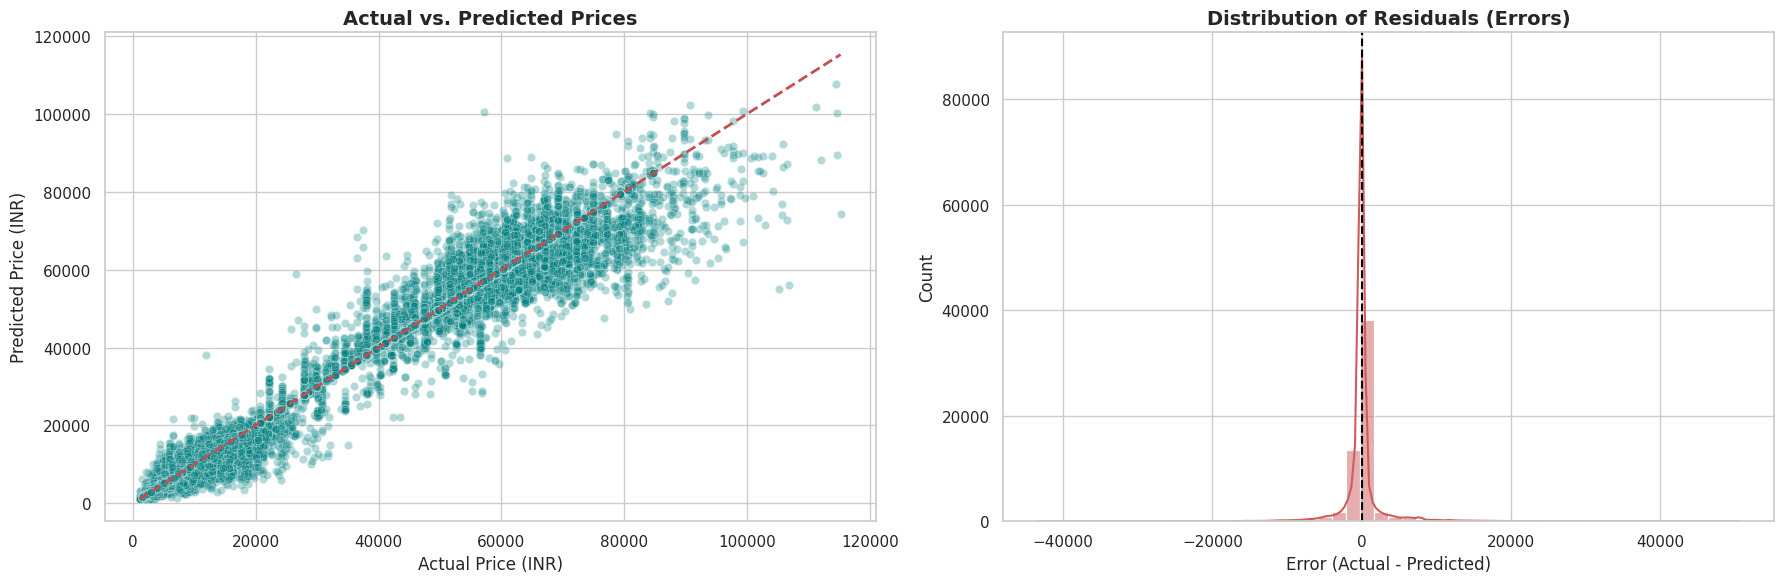

In [45]:
residuals = y_test - y_pred

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

sns.scatterplot(ax=axes[0], x=y_test, y=y_pred, alpha=0.3, color='teal')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0].set_title('Actual vs. Predicted Prices', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Actual Price (INR)')
axes[0].set_ylabel('Predicted Price (INR)')

sns.histplot(ax=axes[1], x=residuals, kde=True, color='indianred', bins=50)
axes[1].axvline(0, color='black', linestyle='--')
axes[1].set_title('Distribution of Residuals (Errors)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Error (Actual - Predicted)')

plt.tight_layout()
plt.show()